In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
import os
path=os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train')
classes={'Without_Tumor':0, 'Tumor':1}


In [3]:
import cv2
X=[]
Y=[]
for cls in classes:
  pth='/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Train/'+cls
  for j in os.listdir(pth):
    img=cv2.imread(pth+'/'+j,0)
    img=cv2.resize(img,(200,200))
    X.append(img)
    Y.append(classes[cls])



In [4]:
X=np.array(X)
Y=np.array(Y)

In [5]:
np.unique(Y)

array([0, 1])

In [6]:
pd.Series(Y).value_counts()

0    1536
1    1451
dtype: int64

In [7]:
X.shape

(2987, 200, 200)

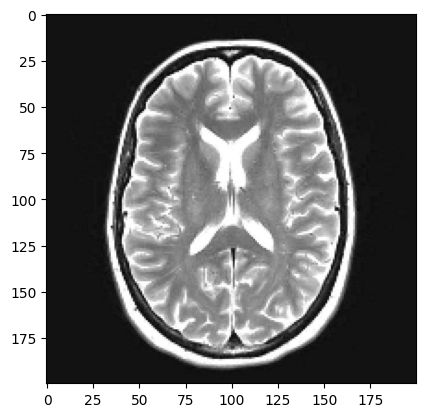

In [8]:
plt.imshow(X[1],cmap='gray')

In [9]:
X_updated=X.reshape(len(X),-1)
X_updated.shape

(2987, 40000)

In [10]:
xtrain,xtest,ytrain,ytest=train_test_split(X_updated,Y,random_state=10,test_size=.20)


In [11]:
print(xtrain.max(),xtrain.min())
print(xtest.max(),xtest.min())
xtrain=xtrain/255
xtest=xtest/255
print(xtrain.max(),xtrain.min())
print(xtest.max(),xtest.min())

255 0
255 0
1.0 0.0
1.0 0.0


In [12]:
from sklearn.decomposition import PCA

In [13]:
print(xtrain.shape,xtest.shape)
pca=PCA(.98)
pca_train=xtrain
pca_test=xtest

(2389, 40000) (598, 40000)


In [14]:
from sklearn.tree import DecisionTreeClassifier


In [15]:
tree = DecisionTreeClassifier()

In [16]:
import warnings
warnings.filterwarnings('ignore')

lg=tree
lg.fit(pca_train, ytrain)

DecisionTreeClassifier()

In [17]:
print("Training Score:", lg.score(pca_train, ytrain))
print("Testning Score:", lg.score(pca_test, ytest))

Training Score: 1.0
Testning Score: 0.8712374581939799


In [18]:
dec={0:'No Tumor', 1:'Positive Tumor'}

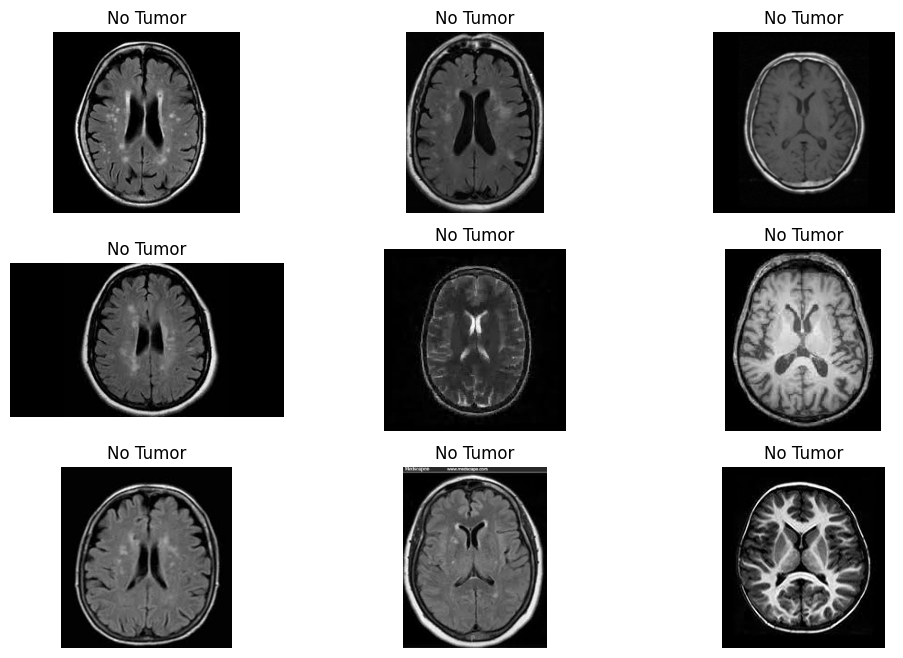

In [19]:
plt.figure(figsize=(12,8))
p = os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test')
c=1
for i in os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/no/')[:9]:
    plt.subplot(3,3,c)

    img = cv2.imread('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/no/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = lg.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1

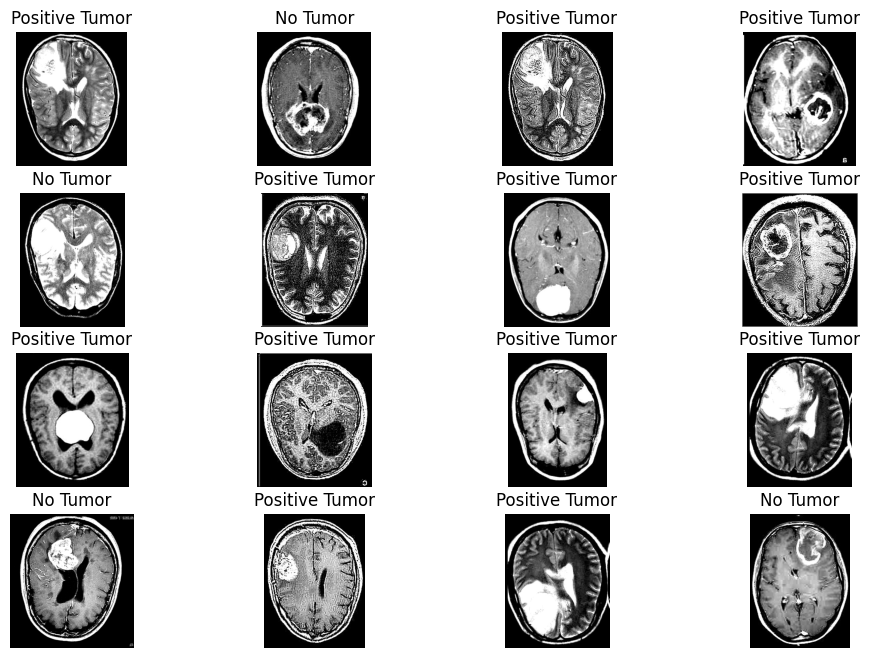

In [20]:
plt.figure(figsize=(12,8))
p = os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test')
c=1
for i in os.listdir('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/yes/')[:16]:
    plt.subplot(4,4,c)

    img = cv2.imread('/content/drive/MyDrive/BrainTumorClassificationProject/BrainTumorDataSet/Test/yes/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = lg.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1

In [21]:
y_pred=lg.predict(xtest)

In [22]:
actual=ytest
predicted=y_pred

In [23]:
df={'actuals':actual, 'predictions': predicted}
df=pd.DataFrame(df)
df

,actuals,predictions
0,1,1
1,1,1
2,0,1
3,0,0
4,0,0
...,...,...
593,0,0
594,1,1
595,1,1
596,0,0


In [24]:
cf_matrix = confusion_matrix(df['actuals'] , df['predictions'])
print(cf_matrix)

[[278  39]
 [ 38 243]]


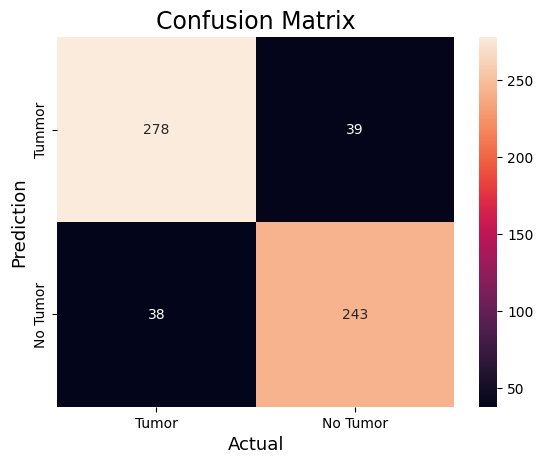

In [25]:
sns.heatmap(cf_matrix,
            annot=True,
            fmt='g',
            xticklabels=['Tumor','No Tumor'],
            yticklabels=['Tummor','No Tumor'])
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

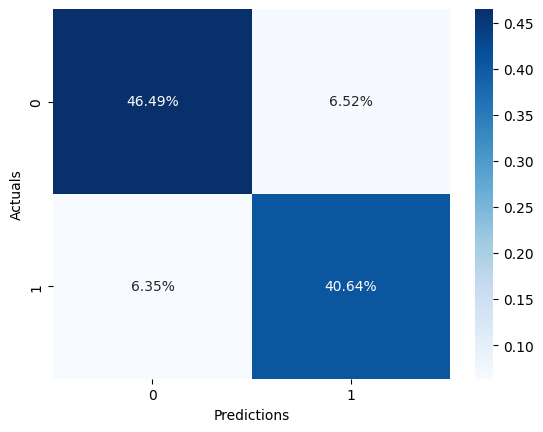

In [26]:
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True,
            fmt='.2%', cmap='Blues')
plt.ylabel('Actuals')
plt.xlabel('Predictions')
plt.show()

In [27]:
# Finding precision and recall

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


accuracy = accuracy_score(ytest, y_pred)
print("Accuracy   :", accuracy)
precision = precision_score(ytest, y_pred)
print("Precision :", precision)
recall = recall_score(ytest, y_pred)
print("Recall    :", recall)
F1_score = f1_score(ytest, y_pred)
print("F1-score  :", F1_score)

Accuracy   : 0.8712374581939799
Precision : 0.8617021276595744
Recall    : 0.8647686832740213
F1-score  : 0.8632326820603907


In [ ]:
True_Negative, True_positive, False_Negative, False_positive= cf_matrix[0][0],cf_matrix[0][1],cf_matrix[1][0],cf_matrix[1][1]
True_Negative, True_positive, False_Negative, False_positive

(278, 39, 41, 240)

In [ ]:
from sklearn.metrics import accuracy_score
score =accuracy_score(df['actuals'] , df['predictions'])

score

0.8662207357859532

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import roc_curve

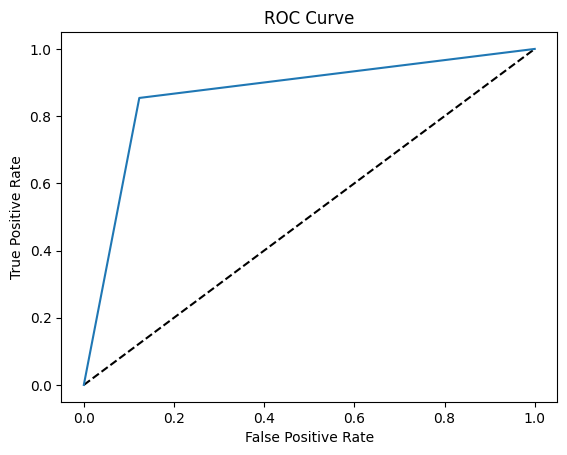

In [ ]:
fpr, tpr, thresholds = roc_curve(df['actuals'] , df['predictions'])
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.metrics import roc_curve

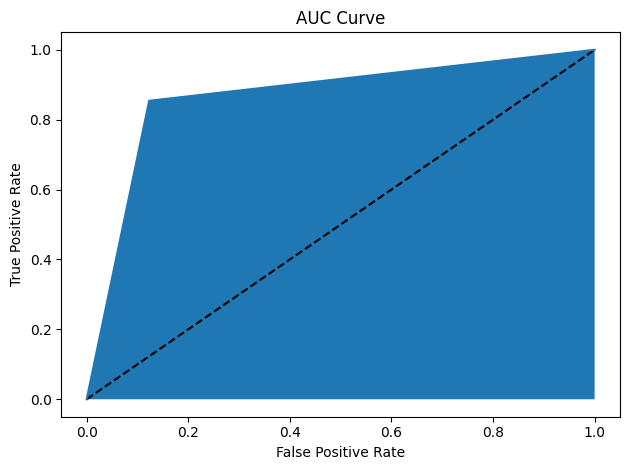

In [ ]:
fpr, tpr, thresholds = roc_curve(df['actuals'] , df['predictions'])

# Plot ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve')

plt.fill_between(fpr, tpr)
plt.tight_layout()
plt.show()

In [ ]:
accuracy=accuracy_score(ytest, y_pred)
print(f'Accuracy: {accuracy*100:.2f}%')

Accuracy: 86.29%
